In [1]:
import os
import json
import numpy as np
import pandas as pdn
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
from seisLM.model.foundation.pretrained_models import LitMultiDimWav2Vec2

CODE_DIR = "/loggerhead/mikedeffino/Code"

torch version: 2.5.1+cu121
cuda available: True


/home/mikedeffino/miniconda3/envs/llava-med2/lib/python3.10/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [5]:
import pandas as pd

CODE_DIR = "/loggerhead/mikedeffino/Code"
csv_path = f"{CODE_DIR}/stage1metric/generation_metrics.csv"

df = pd.read_csv(csv_path)
print(df.head())

print("\nSummary:")
print("num_samples:", len(df))
print("mean_SGS:", df["sgs"].mean())
print("mean_completeness:", df["completeness"].mean())
print("mean_ROUGE_L_F1:", df["rougeL_f1"].mean())
print("station_exact_rate:", df["station_exact"].mean())
print("dominant_exact_rate:", df["dominant_exact"].mean())
print("mean_mag_err:", df["mag_err"].mean())
print("mean_dist_err_km:", df["dist_err_km"].mean())
print("mean_p_err_samples:", df["p_err_samples"].mean())
print("mean_s_err_samples:", df["s_err_samples"].mean())

   idx                 trace_name  \
0    0  AHUD.HV_20180506042619_EV   
1    1  AHUD.HV_20180506060130_EV   
2    2  AHUD.HV_20180506072221_EV   
3    3  AHUD.HV_20180506084248_EV   
4    4  AHUD.HV_20180506101131_EV   

                                        ground_truth  \
0  Local earthquake waveform at station AHUD: M1....   
1  Local earthquake waveform at station AHUD: M2....   
2  Local earthquake waveform at station AHUD: M2....   
3  Local earthquake waveform at station AHUD: M2....   
4  Local earthquake waveform at station AHUD: M1....   

                                           generated       sgs  completeness  \
0  Local earthquake waveform at station AHUD: M1....  0.469444           1.0   
1  Local earthquake waveform at station AHUD: M1....  0.458333           1.0   
2  Local earthquake waveform at station AHUD: M1....  0.580556           1.0   
3  Local earthquake waveform at station AHUD: M1....  0.540278           1.0   
4  Local earthquake waveform at station 

In [9]:
import os
import torch
import os
import torch
import pandas as pd
from pathlib import Path

CODE_DIR = "/loggerhead/mikedeffino/Code"

cfg = Config()
cfg.seislm_checkpoint = f"{CODE_DIR}/epoch=39-step=1203000.ckpt"
cfg.hdf5_path = f"{CODE_DIR}/chunk2.hdf5"
cfg.jsonl_path = f"{CODE_DIR}/waveform_report_m1_d200_expanded120.jsonl"
cfg.device = "cuda" if torch.cuda.is_available() else "cpu"

save_dir = f"{CODE_DIR}/stage1metric"
print("Loading from:", save_dir)
print("Exists:", os.path.exists(save_dir))

model, tokenizer = load_model(cfg, save_dir=save_dir)

test_dataset = PreFilteredSTEADDataset(cfg, tokenizer=tokenizer, stage=1, split="eval")
sample = test_dataset[1]

trace_name = test_dataset.valid_traces[0]
report_obj = test_dataset.reports[trace_name]

if isinstance(report_obj, dict) and "report" in report_obj:
    ground_truth = report_obj["report"]
else:
    ground_truth = str(report_obj)

generated = generate_report(
    model,
    cfg,
    tokenizer,
    sample["waveform"],
    instruction="Describe this seismic event in one sentence."
)

print("trace_name =", trace_name)
print("GT length =", len(ground_truth))
print("GEN length =", len(generated))
print("\nGround truth:\n", ground_truth)
print("\nGenerated:\n", generated)

test_dataset.close()

Loading from: /loggerhead/mikedeffino/Code/stage1metric
Exists: True
📂 Loading from: /loggerhead/mikedeffino/Code/stage1metric
🤖 Loading SeisLM from /loggerhead/mikedeffino/Code/epoch=39-step=1203000.ckpt...
  ✓ SeisLM loaded: 11,359,568 params
  ✓ SeisLM output dim: 256
🤖 Loading sentence encoder...


/home/mikedeffino/miniconda3/envs/llava-med2/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  ✓ Sentence encoder loaded (frozen, dim=384)
  ✓ Projector: Multi-TCN + MoE (3 experts, 8 prefix tokens, dilations=(1, 2, 4))
🤖 Loading LLM: TinyLlama/TinyLlama-1.1B-Chat-v1.0...
  ✓ LLM with LoRA — trainable: 1,126,400 / 1,101,174,784 (0.10%)
  ✓ All weights restored
📥 Loading reports from /loggerhead/mikedeffino/Code/waveform_report_m1_d200_expanded120.jsonl...


/home/mikedeffino/miniconda3/envs/llava-med2/lib/python3.10/site-packages/peft/peft_model.py:556: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  adapters_weights = torch.load

  ✓ Loaded 111,075 expert reports
📥 Opening HDF5: /loggerhead/mikedeffino/Code/chunk2.hdf5
  ✓ [EVAL] 1,000 waveform-report pairs
trace_name = AHUD.HV_20180506042619_EV
GT length = 98
GEN length = 96

Ground truth:
 Local earthquake waveform at station AHUD: M1.7, 12 km, P at 900, S at 1153, dominant N component.

Generated:
 Local earthquake waveform at station AHUD: M1.8, 2 km, P at 503, S at 649, dominant N component.


In [12]:
import os
import torch
import random
from pathlib import Path

CODE_DIR = "/loggerhead/mikedeffino/Code"

cfg = Config()
cfg.seislm_checkpoint = f"{CODE_DIR}/epoch=39-step=1203000.ckpt"
cfg.hdf5_path = f"{CODE_DIR}/chunk2.hdf5"
cfg.jsonl_path = f"{CODE_DIR}/waveform_report_m1_d200_expanded120.jsonl"
cfg.device = "cuda" if torch.cuda.is_available() else "cpu"

save_dir = f"{CODE_DIR}/stage1metric"
print("Loading from:", save_dir)
print("Exists:", os.path.exists(save_dir))

model, tokenizer = load_model(cfg, save_dir=save_dir)

test_dataset = PreFilteredSTEADDataset(cfg, tokenizer=tokenizer, stage=1, split="eval")

num_examples = min(5, len(test_dataset))
indices = random.sample(range(len(test_dataset)), num_examples)

print("Random indices:", indices)

for idx, i in enumerate(indices, 1):
    sample = test_dataset[i]
    trace_name = test_dataset.valid_traces[i]
    report_obj = test_dataset.reports[trace_name]

    if isinstance(report_obj, dict) and "report" in report_obj:
        ground_truth = report_obj["report"]
    else:
        ground_truth = str(report_obj)

    generated = generate_report(
        model,
        cfg,
        tokenizer,
        sample["waveform"],
        instruction="Describe this seismic event in one sentence."
    )

    print("=" * 100)
    print(f"Random Sample {idx}  |  dataset index = {i}")
    print("trace_name =", trace_name)
    print("GT length =", len(ground_truth))
    print("GEN length =", len(generated))
    print("\nGround truth:\n", ground_truth)
    print("\nGenerated:\n", generated)
    print()

test_dataset.close()

Loading from: /loggerhead/mikedeffino/Code/stage1metric
Exists: True
📂 Loading from: /loggerhead/mikedeffino/Code/stage1metric
🤖 Loading SeisLM from /loggerhead/mikedeffino/Code/epoch=39-step=1203000.ckpt...
  ✓ SeisLM loaded: 11,359,568 params
  ✓ SeisLM output dim: 256
🤖 Loading sentence encoder...
  ✓ Sentence encoder loaded (frozen, dim=384)
  ✓ Projector: Multi-TCN + MoE (3 experts, 8 prefix tokens, dilations=(1, 2, 4))
🤖 Loading LLM: TinyLlama/TinyLlama-1.1B-Chat-v1.0...
  ✓ LLM with LoRA — trainable: 1,126,400 / 1,101,174,784 (0.10%)
  ✓ All weights restored
📥 Loading reports from /loggerhead/mikedeffino/Code/waveform_report_m1_d200_expanded120.jsonl...


/tmp/ipykernel_2761114/650528322.py:1043: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f"{save_dir}/projector.pt", map_location=cfg.device)
/tmp/ipykernel_276111

  ✓ Loaded 111,075 expert reports
📥 Opening HDF5: /loggerhead/mikedeffino/Code/chunk2.hdf5
  ✓ [EVAL] 1,000 waveform-report pairs
Random indices: [624, 700, 649, 623, 525]
Random Sample 1  |  dataset index = 624
trace_name = AHUD.HV_20180620123908_EV
GT length = 96
GEN length = 96

Ground truth:
 Local earthquake waveform at station AHUD: M2.4, 3 km, P at 503, S at 668, dominant E component.

Generated:
 Local earthquake waveform at station AHUD: M1.8, 2 km, P at 703, S at 795, dominant N component.

Random Sample 2  |  dataset index = 700
trace_name = AHUD.HV_20180622200242_EV
GT length = 96
GEN length = 96

Ground truth:
 Local earthquake waveform at station AHUD: M2.1, 5 km, P at 824, S at 995, dominant E component.

Generated:
 Local earthquake waveform at station AHUD: M1.8, 2 km, P at 500, S at 634, dominant N component.

Random Sample 3  |  dataset index = 649
trace_name = AHUD.HV_20180621022800_EV
GT length = 97
GEN length = 96

Ground truth:
 Local earthquake waveform at stati

In [ ]:
class Config:
    llm_name          = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
    seislm_checkpoint = "epoch=39-step=1203000.ckpt"
    sample_rate    = 100
    window_size    = 3000
    input_channels = 3
    embed_dim      = None
    llm_dim        = 2048
    num_prefix_tokens = 8
    projector_hidden  = 1024
    cnn_kernel_sizes  = (3, 5, 7)
    tcn_dilations    = (1, 2, 4)
    projector_dropout = 0.10

    batch_size            = 4      
    grad_accum_steps      = 16     
    temperature           = 0.07   
    epochs_stage1         = 20     



    epochs_stage2  = 3           

    lr_stage1      = 1e-4
    lr_stage2      = 2e-5        
    warmup_steps   = 30
    max_grad_norm  = 1.0

    # LoRA hyperparameters
    lora_r         = 8          
    lora_alpha     = 16        
    lora_dropout   = 0.05
    lora_targets   = ["q_proj", "v_proj"]   

    hdf5_path    = "/Users/abirhasanbhuiiyan/Downloads/chunk2/filtered_chunk2.hdf5"
    jsonl_path   = "/Users/abirhasanbhuiiyan/Downloads/waveform_report_m1_d200_expanded120.jsonl"
    device       = "mps" if torch.backends.mps.is_available() else "cpu"
    dtype        = torch.float32
    max_samples  = 10000
    eval_samples     = 1000    
    train_split      = 0.9
    max_text_len = 384



cfg = Config()

print(f"--- EQLM with Official Pretrained SeisLM ---")
print(f"--- Device: {cfg.device} ---")


# ==========================================
# 2. DATASET
# ==========================================
class PreFilteredSTEADDataset(Dataset):
    def __init__(self, cfg, tokenizer=None, stage=1, max_text_len=384, split='train'):
        self.cfg          = cfg
        self.tokenizer    = tokenizer
        self.stage        = stage
        self.max_text_len = max_text_len
        self.split        = split

        # ── Load expert reports ───────────────────────────────────────────────
        print(f"📥 Loading reports from {cfg.jsonl_path}...")
        self.reports = {}
        with open(cfg.jsonl_path, 'r') as f:
            for line in f:
                sample   = json.loads(line.strip())
                trace_id = sample.get('id') or sample.get('trace_name')
                if trace_id:
                    self.reports[trace_id] = {
                        'report':   sample.get('report', 'No report available.'),
                        'metadata': sample.get('metadata', {})
                    }
        print(f"  ✓ Loaded {len(self.reports):,} expert reports")

        # ── Open HDF5 ─────────────────────────────────────────────────────────
        print(f"📥 Opening HDF5: {cfg.hdf5_path}")
        self.hdf5_file  = h5py.File(cfg.hdf5_path, 'r')
        self.data_group = self.hdf5_file['data']

        # ── Build aligned trace list ──────────────────────────────────────────
        self.valid_traces = []
        for trace_name in self.reports.keys():
            if trace_name in self.data_group:
                try:
                    wf = np.array(self.data_group[trace_name])
                    if wf.shape == (6000, 3):
                        self.valid_traces.append(trace_name)
                except:
                    continue

        # Cap total before splitting so max_samples is the combined budget
        self.valid_traces = self.valid_traces[:cfg.max_samples]

        # ── Train / eval split ────────────────────────────────────────────────
        n_train = int(len(self.valid_traces) * cfg.train_split)
        if split == 'train':
            self.valid_traces = self.valid_traces[:n_train]
        elif split == 'eval':
            self.valid_traces = self.valid_traces[n_train:]
        else:
            raise ValueError(f"split must be 'train' or 'eval', got '{split}'")

        print(f"  ✓ [{split.upper()}] {len(self):,} waveform-report pairs")

    # ── Length ────────────────────────────────────────────────────────────────
    def __len__(self):
        return len(self.valid_traces)

    # ── Item fetching ─────────────────────────────────────────────────────────
    def __getitem__(self, idx):
        trace_name  = self.valid_traces[idx]
        report_data = self.reports[trace_name]
        expert_report = report_data['report']
        metadata      = report_data.get('metadata', {})

        try:
            dataset = self.data_group.get(trace_name)
            if dataset is None:
                return self._get_synthetic_sample(expert_report, metadata, trace_name)

            waveform = np.array(dataset)
            if waveform.shape == (6000, 3):
                waveform = waveform.T                         

            # Centre-crop to window_size
            if waveform.shape[1] > self.cfg.window_size:
                start    = (waveform.shape[1] - self.cfg.window_size) // 2
                waveform = waveform[:, start:start + self.cfg.window_size]
            elif waveform.shape[1] < self.cfg.window_size:
                pad      = self.cfg.window_size - waveform.shape[1]
                waveform = np.pad(waveform, ((0, 0), (0, pad)), mode='constant')

            # Per-channel z-score normalisation
            for ch in range(3):
                mean = np.mean(waveform[ch])
                std  = np.std(waveform[ch]) + 1e-8
                waveform[ch] = (waveform[ch] - mean) / std

            waveform = torch.tensor(waveform, dtype=torch.float32)

        except Exception:
            return self._get_synthetic_sample(expert_report, metadata, trace_name)

        # ── Stage 2: instruction tuning format ───────────────────────────────
        if self.stage == 2:
           instruction = self._generate_instruction(metadata)
           prompt = f"User: {instruction}\nAssistant:"
           full_text = prompt + " " + expert_report.strip() + tokenizer.eos_token

           if self.tokenizer:
              enc_full = self.tokenizer(
                full_text,
                max_length=self.max_text_len,
                truncation=True,
                padding='max_length',
                return_tensors='pt'
        )
              enc_prompt = self.tokenizer(
                prompt,
                max_length=self.max_text_len,
                truncation=True,
                padding=False,
                return_tensors='pt'
        )

              input_ids = enc_full["input_ids"].squeeze(0)
              attention_mask = enc_full["attention_mask"].squeeze(0)
              labels = input_ids.clone()

              prompt_len = min(enc_prompt["input_ids"].shape[1], labels.shape[0])
              labels[:prompt_len] = -100
              labels[attention_mask == 0] = -100

              return {
                  "waveform": waveform,
                  "input_ids": input_ids,
                  "attention_mask": attention_mask,
                  "labels": labels,
                  "instruction": instruction,
                  "expert_report": expert_report,
                  "trace_name": trace_name,
                  "metadata": json.dumps({k: str(v) for k, v in metadata.items()}) if metadata else "{}"
        }

        # ── Stage 1: contrastive alignment format ─────────────────────────────
        else:
            if self.tokenizer:
                encoding = self.tokenizer(
                    expert_report,
                    max_length=self.max_text_len,
                    truncation=True,
                    padding='max_length',
                    return_tensors='pt'
                )
                return {
                    'waveform':       waveform,
                    'input_ids':      encoding['input_ids'].squeeze(0),
                    'attention_mask': encoding['attention_mask'].squeeze(0),
                    'caption':        expert_report,
                    'trace_name':     trace_name
                }

        return {'waveform': waveform, 'trace_name': trace_name}

    # ── Helpers ───────────────────────────────────────────────────────────────
    def _generate_instruction(self, metadata):
        instructions = [
            "Describe this seismic event in detail.",
            "Generate a preliminary earthquake report.",
            "What can you tell me about this earthquake?",
            "Analyze the seismic waveform and summarize findings.",
            "Provide an emergency response summary for this event."
        ]
        return np.random.choice(instructions)

    def _get_synthetic_sample(self, report, metadata, trace_name):
        waveform = torch.randn(3, self.cfg.window_size, dtype=torch.float32)
        if self.stage == 2:
            metadata_str = json.dumps(
                {k: str(v) for k, v in metadata.items()}
            ) if metadata else "{}"
            return {
                'waveform':      waveform,
                'instruction':   self._generate_instruction(metadata),
                'expert_report': report,
                'trace_name':    trace_name,
                'metadata':      metadata_str
            }
        return {
            'waveform':   waveform,
            'caption':    report,
            'trace_name': trace_name
        }

    # ── Cleanup ───────────────────────────────────────────────────────────────
    def close(self):
        self.hdf5_file.close()

    def __del__(self):
        if hasattr(self, 'hdf5_file'):
            try:
                self.hdf5_file.close()
            except:
                pass


# ==========================================
# 3. MODEL: Fixed SeisLM Output Handling
# ==========================================

class TemporalResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.1):
        super().__init__()
        padding = dilation * (kernel_size - 1) // 2

        self.conv1 = nn.Conv1d(
            in_channels, out_channels, kernel_size,
            padding=padding, dilation=dilation
        )
        self.norm1 = nn.GroupNorm(1, out_channels)

        self.conv2 = nn.Conv1d(
            out_channels, out_channels, kernel_size,
            padding=padding, dilation=dilation
        )
        self.norm2 = nn.GroupNorm(1, out_channels)

        self.dropout = nn.Dropout(dropout)
        self.act = nn.GELU()
        self.residual = (
            nn.Conv1d(in_channels, out_channels, kernel_size=1)
            if in_channels != out_channels else nn.Identity()
        )

    def forward(self, x):
        residual = self.residual(x)

        out = self.conv1(x)
        out = self.act(out)
        out = self.norm1(out)
        out = self.dropout(out)

        out = self.conv2(out)
        out = self.act(out)
        out = self.norm2(out)
        out = self.dropout(out)

        return self.act(out + residual)


class TCNExpert(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, dilations=(1, 2, 4), dropout=0.1):
        super().__init__()
        self.input_proj = nn.Conv1d(input_dim, hidden_dim, kernel_size=1)
        self.blocks = nn.ModuleList([
            TemporalResidualBlock(hidden_dim, hidden_dim, kernel_size, d, dropout=dropout)
            for d in dilations
        ])
        self.out_norm = nn.GroupNorm(1, hidden_dim)

    def forward(self, x):
        # x: [B, T, D] -> TCN expects [B, D, T]
        x = x.transpose(1, 2)
        x = self.input_proj(x)
        for block in self.blocks:
            x = block(x)
        x = self.out_norm(x)
        return x.mean(dim=-1)   # [B, hidden_dim]


class MultiTCNMoEProjector(nn.Module):
    def __init__(
        self,
        input_dim,
        output_dim,
        num_prefix_tokens=8,
        hidden_dim=1024,
        kernel_sizes=(3, 5, 7),
        dilations=(1, 2, 4),
        dropout=0.1
    ):
        super().__init__()
        self.num_prefix_tokens = num_prefix_tokens
        self.hidden_dim = hidden_dim

        self.experts = nn.ModuleList([
            TCNExpert(input_dim, hidden_dim, k, dilations=dilations, dropout=dropout)
            for k in kernel_sizes
        ])

        self.gate = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, len(kernel_sizes))
        )

        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.LayerNorm(hidden_dim)
        )

        self.token_queries = nn.Parameter(
            torch.randn(num_prefix_tokens, hidden_dim) * 0.02
        )

        self.output_proj = nn.Sequential(
            nn.Linear(hidden_dim, output_dim),
            nn.LayerNorm(output_dim)
        )

        self.log_temperature = nn.Parameter(torch.tensor([-2.659]))  # log(0.07)

    def encode_features(self, x):
        """
        x can be:
          [B, T, D]  -> SeisLM sequence features
          [B, D]     -> already pooled features
        returns:
          [B, hidden_dim] pooled temporal feature after TCN + MoE fusion
        """
        if x.dim() == 2:
            x = x.unsqueeze(1)

        pooled = x.mean(dim=1)                                
        gate_logits = self.gate(pooled)                       
        gate_weights = F.softmax(gate_logits, dim=-1)         

        expert_features = torch.stack(
            [expert(x) for expert in self.experts], dim=1
        )                                                     

        fused = (gate_weights.unsqueeze(-1) * expert_features).sum(dim=1) 
        fused = self.fusion(fused)                           
        return fused

    def forward(self, x):
        fused = self.encode_features(x)                       
        token_states = fused.unsqueeze(1) + self.token_queries.unsqueeze(0) 
        prefix_tokens = self.output_proj(token_states)       
        return prefix_tokens

    @property
    def temperature(self):
        return self.log_temperature.exp().clamp(min=0.01, max=0.5)


from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from transformers import AutoModel, AutoTokenizer, AutoModelForCausalLM

class EQLM(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg

        # ── SeisLM (frozen) ──────────────────────────────────────────────────
        print(f"🤖 Loading SeisLM from {cfg.seislm_checkpoint}...")
        lit_model = LitMultiDimWav2Vec2.load_from_checkpoint(
            cfg.seislm_checkpoint,
            map_location='cpu',
            weights_only=False
        )
        self.seislm = lit_model.model.to(cfg.device).eval()
        for p in self.seislm.parameters():
            p.requires_grad = False
        print(f"  ✓ SeisLM loaded: {sum(p.numel() for p in self.seislm.parameters()):,} params")

        # ── Auto-detect SeisLM output dim ────────────────────────────────────
        cfg.embed_dim = self._probe_embed_dim()
        print(f"  ✓ SeisLM output dim: {cfg.embed_dim}")

        # ── Sentence encoder for Stage 1 contrastive alignment (frozen) ──────
        # Produces meaningful 384-dim sentence embeddings — far better than
        # raw LLM input embeddings which are untrained at the sentence level.
        print(f"🤖 Loading sentence encoder...")
        self.text_encoder = AutoModel.from_pretrained(
            "sentence-transformers/all-MiniLM-L6-v2"
        ).to(cfg.device)
        for p in self.text_encoder.parameters():
            p.requires_grad = False
        cfg.text_dim = 384   # all-MiniLM-L6-v2 output dim
        print(f"  ✓ Sentence encoder loaded (frozen, dim={cfg.text_dim})")

        # ── Shared alignment dim ─────────────────────────────────────────────
        # Both seismic and text embeddings are projected into this space
        cfg.align_dim = 256

        # Seismic temporal projector used in both stages:
        # Stage 1: TCN + MoE temporal pooling -> alignment head
        # Stage 2: TCN + MoE -> prefix tokens for the LLM
        self.projector = MultiTCNMoEProjector(
            cfg.embed_dim,
            cfg.llm_dim,
            num_prefix_tokens=cfg.num_prefix_tokens,
            hidden_dim=cfg.projector_hidden,
            kernel_sizes=cfg.cnn_kernel_sizes,
            dilations=cfg.tcn_dilations,
            dropout=cfg.projector_dropout
        ).to(cfg.device)
        print(f"  ✓ Projector: Multi-TCN + MoE ({len(cfg.cnn_kernel_sizes)} experts, {cfg.num_prefix_tokens} prefix tokens, dilations={cfg.tcn_dilations})")

        # Separate lightweight head for contrastive alignment only
        # Projects TCN-pooled seismic features → shared 256-dim space
        self.seismic_align_head = nn.Sequential(
            nn.Linear(cfg.projector_hidden, cfg.align_dim),
            nn.GELU(),
            nn.LayerNorm(cfg.align_dim)
        ).to(cfg.device)

        # Projects sentence embeddings → shared 256-dim space
        self.text_align_head = nn.Sequential(
            nn.Linear(cfg.text_dim, cfg.align_dim),
            nn.GELU(),
            nn.LayerNorm(cfg.align_dim)
        ).to(cfg.device)

        # ── LLM base ─────────────────────────────────────────────────────────
        print(f"🤖 Loading LLM: {cfg.llm_name}...")
        base_llm = AutoModelForCausalLM.from_pretrained(
            cfg.llm_name,
            torch_dtype=cfg.dtype
        )
        base_llm.config.pad_token_id = base_llm.config.eos_token_id

        # ── Wrap LLM with LoRA ───────────────────────────────────────────────
        lora_config = LoraConfig(
            task_type=TaskType.CAUSAL_LM,
            r=cfg.lora_r,
            lora_alpha=cfg.lora_alpha,
            lora_dropout=cfg.lora_dropout,
            target_modules=cfg.lora_targets,
            bias="none",
            inference_mode=False
        )
        self.llm = get_peft_model(base_llm, lora_config)
        self.llm.to(cfg.device)

        trainable, total = self._count_params(self.llm)
        print(f"  ✓ LLM with LoRA — trainable: {trainable:,} / {total:,} "
              f"({100*trainable/total:.2f}%)")

    # ── Helpers ──────────────────────────────────────────────────────────────
    @staticmethod
    def _count_params(model):
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in model.parameters())
        return trainable, total

    @torch.no_grad()
    def _probe_embed_dim(self):
        dummy = torch.zeros(1, self.cfg.input_channels, self.cfg.window_size,
                            device=self.cfg.device)
        out = self.seislm(dummy)
        return self._extract_features(out).shape[-1]

    @staticmethod
    def _extract_features(seislm_output):
        if hasattr(seislm_output, 'last_hidden_state') \
                and seislm_output.last_hidden_state is not None:
            return seislm_output.last_hidden_state
        if hasattr(seislm_output, 'projected_states') \
                and seislm_output.projected_states is not None:
            return seislm_output.projected_states
        if hasattr(seislm_output, 'hidden_states') \
                and seislm_output.hidden_states is not None:
            return seislm_output.hidden_states[-1]
        if isinstance(seislm_output, (tuple, list)) and seislm_output[0] is not None:
            return seislm_output[0]
        raise RuntimeError(f"Cannot extract features from: {type(seislm_output)}")

    def encode_text(self, input_ids, attention_mask):
        """
        Mean-pooled sentence embedding from the frozen sentence encoder.
        Returns [B, 384].
        """
        with torch.no_grad():
            out       = self.text_encoder(input_ids=input_ids,
                                          attention_mask=attention_mask)
            token_emb = out.last_hidden_state                      
            mask      = attention_mask.unsqueeze(-1).float()
            # Masked mean pooling
            sentence_emb = (token_emb * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        return sentence_emb                                          

    # ── Forward ──────────────────────────────────────────────────────────────
    def forward(self, waveforms, input_ids=None, attention_mask=None,
                labels=None, stage=1):

        # Seismic encoding (always frozen)
        with torch.no_grad():
            seismic_features = self._extract_features(self.seislm(waveforms))

        # ── Stage 1: contrastive alignment ───────────────────────────────────
        if stage == 1:
            # TCN + MoE temporal pooling before alignment
            seismic_temporal = self.projector.encode_features(seismic_features)  
            wav_aligned = self.seismic_align_head(seismic_temporal)             

            # Encode text with sentence encoder → shared alignment space
            txt_emb     = self.encode_text(input_ids, attention_mask)  
            txt_aligned = self.text_align_head(txt_emb)            

            return wav_aligned, txt_aligned

        # ── Stage 2: instruction tuning ───────────────────────────────────────
        # Project the full SeisLM sequence with Multi-TCN + MoE
        projected_emb = self.projector(seismic_features)             

        batch_size    = waveforms.shape[0]
        prefix_length = projected_emb.shape[1]

        text_emb      = self.llm.get_input_embeddings()(input_ids)    
        combined_emb  = torch.cat([projected_emb, text_emb], dim=1)   

        prefix_mask      = torch.ones(batch_size, prefix_length,
                                      device=attention_mask.device)
        combined_mask    = torch.cat([prefix_mask, attention_mask], dim=1)

        if labels is not None:
            prefix_labels   = torch.full((batch_size, prefix_length), -100,
                                         dtype=labels.dtype, device=labels.device)
            combined_labels = torch.cat([prefix_labels, labels], dim=1)
        else:
            combined_labels = None

        return self.llm(
            inputs_embeds=combined_emb,
            attention_mask=combined_mask,
            labels=combined_labels
        )



# ==========================================
# 4. TRAINING FUNCTIONS
# ==========================================
'''
def contrastive_loss(sim_matrix, temperature=0.07):
    batch_size = sim_matrix.shape[0]
    labels = torch.arange(batch_size).to(sim_matrix.device)
    loss_i = F.cross_entropy(sim_matrix / temperature, labels)
    loss_j = F.cross_entropy(sim_matrix.T / temperature, labels)
    return (loss_i + loss_j) / 2

'''

def contrastive_loss(wav_emb, txt_emb, temperature=0.07, hard_neg_weight=0.5):
    """
    Mix standard in-batch negatives with hard negatives (closest wrong pairs).
    """
    batch_size = wav_emb.shape[0]
    labels     = torch.arange(batch_size, device=wav_emb.device)

    sim = torch.matmul(wav_emb, txt_emb.T)  # [B, B]

    # Standard contrastive loss
    loss_standard = (F.cross_entropy(sim / temperature, labels) +
                     F.cross_entropy(sim.T / temperature, labels)) / 2

    # Hard negative: for each anchor, find the hardest wrong negative
    with torch.no_grad():
        # Mask out the diagonal (correct pairs)
        sim_masked = sim.clone()
        sim_masked.fill_diagonal_(-1e9)
        hard_neg_idx = sim_masked.argmax(dim=1)  

    hard_neg_txt   = txt_emb[hard_neg_idx]       
    pos_sim        = (wav_emb * txt_emb).sum(dim=1, keepdim=True)  
    neg_sim        = (wav_emb * hard_neg_txt).sum(dim=1, keepdim=True)  
    hard_logits    = torch.cat([pos_sim, neg_sim], dim=1) / temperature
    hard_labels    = torch.zeros(batch_size, dtype=torch.long, device=wav_emb.device)
    loss_hard      = F.cross_entropy(hard_logits, hard_labels)

    return loss_standard + hard_neg_weight * loss_hard


def train_stage1(model, cfg, tokenizer):
    print(f"\n{'='*70}")
    print("STAGE 1: CONTRASTIVE ALIGNMENT")
    print(f"{'='*70}")

    # Freeze only SeisLM and LLM.
    # Stage 1 now trains the temporal projector as well, because the
    # seismic alignment path uses TCN + MoE pooled features.
    for p in model.seislm.parameters():
        p.requires_grad = False
    for p in model.llm.parameters():
        p.requires_grad = False
    for p in model.projector.parameters():
        p.requires_grad = True

    trainable_params = (
        list(model.projector.parameters()) +
        list(model.seismic_align_head.parameters()) +
        list(model.text_align_head.parameters())
    )

    optimizer = torch.optim.AdamW(
        trainable_params,
        lr=cfg.lr_stage1,
        weight_decay=0.01
    )

    train_dataset = PreFilteredSTEADDataset(
        cfg, tokenizer=tokenizer, stage=1, split='train'
    )
    val_dataset = PreFilteredSTEADDataset(
        cfg, tokenizer=tokenizer, stage=1, split='eval'
    )

    train_loader = DataLoader(
        train_dataset, batch_size=cfg.batch_size,
        shuffle=True, num_workers=0
    )
    val_loader = DataLoader(
        val_dataset, batch_size=cfg.batch_size,
        shuffle=False, num_workers=0
    )

    train_loss_history = []
    val_loss_history = []

    for epoch in range(cfg.epochs_stage1):
        # ======================
        # Train
        # ======================
        model.train()
        epoch_loss = 0.0
        valid_updates = 0

        optimizer.zero_grad()
        accumulated_wav, accumulated_txt = [], []

        for batch_idx, batch in enumerate(train_loader):
            waveforms = batch["waveform"].to(cfg.device)
            input_ids = batch["input_ids"].to(cfg.device)
            attention_mask = batch["attention_mask"].to(cfg.device)

            wav_emb, txt_emb = model(waveforms, input_ids, attention_mask, stage=1)
            accumulated_wav.append(F.normalize(wav_emb, p=2, dim=1))
            accumulated_txt.append(F.normalize(txt_emb, p=2, dim=1))

            if ((batch_idx + 1) % cfg.grad_accum_steps == 0) or ((batch_idx + 1) == len(train_loader)):
                wav_big = torch.cat(accumulated_wav, dim=0)
                txt_big = torch.cat(accumulated_txt, dim=0)

                loss = contrastive_loss(
                    wav_big,
                    txt_big,
                    temperature=model.projector.temperature
                )

                if torch.isfinite(loss):
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(trainable_params, cfg.max_grad_norm)
                    optimizer.step()
                    epoch_loss += loss.item()
                    valid_updates += 1
                else:
                    print(f"  ⚠ Non-finite loss at batch {batch_idx} — skipping")

                optimizer.zero_grad()
                accumulated_wav, accumulated_txt = [], []

                if batch_idx % 20 == 0:
                    print(
                        f"  Epoch {epoch+1} Batch {batch_idx}/{len(train_loader)} "
                        f"Loss: {loss.item():.4f} "
                        f"Temp: {model.projector.temperature.item():.4f}"
                    )

        avg_train = epoch_loss / max(1, valid_updates)

        # ======================
        # Validation
        # ======================
        model.eval()
        val_loss = 0.0
        val_batches = 0

        with torch.no_grad():
            for batch in val_loader:
                waveforms = batch["waveform"].to(cfg.device)
                input_ids = batch["input_ids"].to(cfg.device)
                attention_mask = batch["attention_mask"].to(cfg.device)

                wav_emb, txt_emb = model(waveforms, input_ids, attention_mask, stage=1)
                wav_emb = F.normalize(wav_emb, p=2, dim=1)
                txt_emb = F.normalize(txt_emb, p=2, dim=1)

                loss = contrastive_loss(
                    wav_emb,
                    txt_emb,
                    temperature=model.projector.temperature
                )

                if torch.isfinite(loss):
                    val_loss += loss.item()
                    val_batches += 1

        avg_val = val_loss / max(1, val_batches)

        train_loss_history.append(avg_train)
        val_loss_history.append(avg_val)

        print(
            f"Epoch {epoch+1}/{cfg.epochs_stage1} "
            f"Train: {avg_train:.4f}  Val: {avg_val:.4f}"
        )

    train_dataset.close()
    val_dataset.close()

    return model, train_loss_history, val_loss_history

def train_stage2(model, cfg, tokenizer):
    print(f"\n{'='*70}")
    print("STAGE 2: INSTRUCTION TUNING (Projector + LoRA)")
    print(f"{'='*70}")

    if tokenizer.pad_token_id == tokenizer.eos_token_id:
        tokenizer.add_special_tokens({'pad_token': '[PAD]'})
        model.llm.resize_token_embeddings(len(tokenizer))
        print(f"  ✓ Added dedicated [PAD] token (id={tokenizer.pad_token_id})")

    for p in model.projector.parameters():
        p.requires_grad = True

    optimizer = torch.optim.AdamW([
        {
            'params': model.projector.parameters(),
            'lr': cfg.lr_stage2 * 5,
            'weight_decay': 0.01
        },
        {
            'params': [p for p in model.llm.parameters() if p.requires_grad],
            'lr': cfg.lr_stage2,
            'weight_decay': 0.01
        }
    ], eps=1e-7)

    train_dataset = PreFilteredSTEADDataset(
        cfg, tokenizer=tokenizer, stage=2,
        max_text_len=cfg.max_text_len, split='train'
    )
    val_dataset = PreFilteredSTEADDataset(
        cfg, tokenizer=tokenizer, stage=2,
        max_text_len=cfg.max_text_len, split='eval'
    )

    train_loader = DataLoader(
        train_dataset, batch_size=cfg.batch_size,
        shuffle=True, num_workers=0
    )
    val_loader = DataLoader(
        val_dataset, batch_size=cfg.batch_size,
        shuffle=False, num_workers=0
    )

    total_steps = len(train_loader) * cfg.epochs_stage2

    def lr_lambda(step):
        if step < cfg.warmup_steps:
            return step / max(1, cfg.warmup_steps)
        progress = (step - cfg.warmup_steps) / max(1, total_steps - cfg.warmup_steps)
        return max(0.05, 0.5 * (1.0 + np.cos(np.pi * progress)))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    if hasattr(model.llm, 'enable_input_require_grads'):
        model.llm.enable_input_require_grads()

    train_loss_history = []
    val_loss_history = []

    best_eval_loss = float('inf')
    patience_count = 0
    patience = 3
    best_proj_state = None

    for epoch in range(cfg.epochs_stage2):
        # ======================
        # Train
        # ======================
        model.train()
        epoch_loss = 0.0
        valid_batches = 0

        for batch_idx, batch in enumerate(train_loader):
            waveforms = batch["waveform"].to(cfg.device)
            input_ids = batch["input_ids"].to(cfg.device)
            attention_mask = batch["attention_mask"].to(cfg.device)
            labels = batch["labels"].to(cfg.device)

            labels_masked = labels.clone()
            labels_masked[labels_masked == tokenizer.pad_token_id] = -100

            optimizer.zero_grad()
            outputs = model(
                waveforms,
                input_ids,
                attention_mask,
                labels=labels_masked,
                stage=2
            )
            loss = outputs.loss

            if not torch.isfinite(loss):
                print(f"  ⚠ Non-finite loss at batch {batch_idx} — skipping")
                optimizer.zero_grad()
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                list(model.projector.parameters()) +
                [p for p in model.llm.parameters() if p.requires_grad],
                cfg.max_grad_norm
            )
            optimizer.step()
            scheduler.step()

            epoch_loss += loss.item()
            valid_batches += 1

            if batch_idx % 10 == 0:
                lr_now = scheduler.get_last_lr()[0]
                print(
                    f"  Epoch {epoch+1} Batch {batch_idx}/{len(train_loader)} "
                    f"Loss: {loss.item():.4f}  LR: {lr_now:.2e}"
                )

        avg_train = epoch_loss / max(1, valid_batches)

        # ======================
        # Validation
        # ======================
        model.eval()
        eval_loss = 0.0
        eval_batches = 0

        with torch.no_grad():
            for batch in val_loader:
                waveforms = batch["waveform"].to(cfg.device)
                input_ids = batch["input_ids"].to(cfg.device)
                attention_mask = batch["attention_mask"].to(cfg.device)
                labels = batch["labels"].to(cfg.device)

                labels_masked = labels.clone()
                labels_masked[labels_masked == tokenizer.pad_token_id] = -100

                out = model(
                    waveforms,
                    input_ids,
                    attention_mask,
                    labels=labels_masked,
                    stage=2
                )

                if torch.isfinite(out.loss):
                    eval_loss += out.loss.item()
                    eval_batches += 1

        avg_val = eval_loss / max(1, eval_batches)

        train_loss_history.append(avg_train)
        val_loss_history.append(avg_val)

        print(
            f"Epoch {epoch+1}/{cfg.epochs_stage2} "
            f"Train: {avg_train:.4f}  Val: {avg_val:.4f}"
        )

        if avg_val < best_eval_loss:
            best_eval_loss = avg_val
            patience_count = 0
            best_proj_state = {
                k: v.detach().cpu().clone()
                for k, v in model.projector.state_dict().items()
            }
            print(f"  ✓ New best val loss: {best_eval_loss:.4f}")
        else:
            patience_count += 1
            print(f"  • No improvement ({patience_count}/{patience})")
            if patience_count >= patience:
                print("  ⏹ Early stopping triggered")
                break

    if best_proj_state is not None:
        model.projector.load_state_dict(best_proj_state)
        print(f"  ✓ Restored best projector (val loss: {best_eval_loss:.4f})")

    train_dataset.close()
    val_dataset.close()

    return model, train_loss_history, val_loss_history





# ==========================================
# 5. EVALUATION
# ==========================================
class EQLMEvaluator:
    def __init__(self, model, cfg, tokenizer):
        self.model = model
        self.cfg = cfg
        self.tokenizer = tokenizer

    def alignment_accuracy(self, dataloader, threshold=0.5):
        self.model.eval()
        alignments = []

        with torch.no_grad():
            for batch in dataloader:
                waveforms = batch["waveform"].to(self.cfg.device)
                input_ids = batch["input_ids"].to(self.cfg.device)
                attention_mask = batch["attention_mask"].to(self.cfg.device)

                wav_emb, txt_emb = self.model(waveforms, input_ids, attention_mask, stage=1)
                wav_emb = F.normalize(wav_emb, p=2, dim=1)
                txt_emb = F.normalize(txt_emb, p=2, dim=1)

                sims = F.cosine_similarity(wav_emb, txt_emb, dim=1)
                alignments.append(sims.cpu().numpy())

        alignments = np.concatenate(alignments)
        return {
            'mean_alignment': float(alignments.mean()),
            'accuracy_threshold': float((alignments > threshold).mean()),
            'std_alignment': float(alignments.std())
        }

    def retrieval_at_k(self, dataloader, k_values=[1, 5, 10]):
        self.model.eval()
        all_wav_embs, all_txt_embs = [], []

        with torch.no_grad():
            for batch in dataloader:
                waveforms = batch["waveform"].to(self.cfg.device)
                input_ids = batch["input_ids"].to(self.cfg.device)
                attention_mask = batch["attention_mask"].to(self.cfg.device)

                wav_emb, txt_emb = self.model(waveforms, input_ids, attention_mask, stage=1)
                all_wav_embs.append(F.normalize(wav_emb, p=2, dim=1).cpu().numpy())
                all_txt_embs.append(F.normalize(txt_emb, p=2, dim=1).cpu().numpy())

        wav_embs = np.vstack(all_wav_embs)
        txt_embs = np.vstack(all_txt_embs)
        n = len(wav_embs)

        results = {}
        for k in k_values:
            correct = sum(1 for i in range(n) if i in np.argsort(wav_embs[i] @ txt_embs.T)[-k:])
            results[f'retrieval@{k}'] = correct / n
        return results

# ==========================================
# 6. SAVE / LOAD UTILITIES
# ==========================================
def save_model(model, tokenizer, save_dir="eqlm_lora_checkpoint"):
    os.makedirs(save_dir, exist_ok=True)

    model.llm.save_pretrained(f"{save_dir}/lora_adapters")
    print(f"  ✓ LoRA adapters       → {save_dir}/lora_adapters")

    torch.save(model.projector.state_dict(),         f"{save_dir}/projector.pt")
    torch.save(model.seismic_align_head.state_dict(),f"{save_dir}/seismic_align_head.pt")
    torch.save(model.text_align_head.state_dict(),   f"{save_dir}/text_align_head.pt")
    print(f"  ✓ Projector           → {save_dir}/projector.pt")
    print(f"  ✓ Seismic align head  → {save_dir}/seismic_align_head.pt")
    print(f"  ✓ Text align head     → {save_dir}/text_align_head.pt")

    tokenizer.save_pretrained(f"{save_dir}/tokenizer")
    print(f"  ✓ Tokenizer           → {save_dir}/tokenizer")

    cfg_dict = {k: v for k, v in vars(cfg.__class__).items()
                if not k.startswith('_') and not callable(v)}
    with open(f"{save_dir}/config.json", 'w') as f:
        json.dump(cfg_dict, f, indent=2, default=str)
    print(f"  ✓ Config              → {save_dir}/config.json")


def load_model(cfg, save_dir="eqlm_lora_checkpoint"):
    save_dir  = str(Path(save_dir).resolve())
    print(f"📂 Loading from: {save_dir}")

    tokenizer = AutoTokenizer.from_pretrained(
        f"{save_dir}/tokenizer", local_files_only=True
    )

    model     = EQLM(cfg).to(cfg.device)
    base_llm  = model.llm.base_model.model
    model.llm = PeftModel.from_pretrained(
        base_llm, f"{save_dir}/lora_adapters", local_files_only=True
    ).to(cfg.device)

    model.projector.load_state_dict(
        torch.load(f"{save_dir}/projector.pt", map_location=cfg.device)
    )
    model.seismic_align_head.load_state_dict(
        torch.load(f"{save_dir}/seismic_align_head.pt", map_location=cfg.device)
    )
    model.text_align_head.load_state_dict(
        torch.load(f"{save_dir}/text_align_head.pt", map_location=cfg.device)
    )

    print("  ✓ All weights restored")
    return model, tokenizer

# ==========================================
# 7. LOSS CURVE PLOTTING
# ==========================================
def save_loss_curves(stage1_train_loss, stage1_val_loss,
                     stage2_train_loss, stage2_val_loss,
                     save_dir="eqlm_lora_checkpoint"):
    os.makedirs(save_dir, exist_ok=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("EQLM Training Loss Curves", fontsize=14, fontweight='bold')

    # ======================
    # Stage 1
    # ======================
    ax1 = axes[0]
    epochs1 = range(1, len(stage1_train_loss) + 1)

    ax1.plot(epochs1, stage1_train_loss, marker='o', linewidth=2, label='Train Loss')
    ax1.plot(epochs1, stage1_val_loss, marker='s', linewidth=2, label='Val Loss')

    ax1.set_title("Stage 1 — Contrastive Alignment")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Contrastive Loss")
    ax1.set_xticks(list(epochs1))
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    for i, v in enumerate(stage1_train_loss):
        ax1.annotate(f"{v:.4f}", (i + 1, v),
                     textcoords="offset points", xytext=(0, 8),
                     ha='center', fontsize=8)

    for i, v in enumerate(stage1_val_loss):
        ax1.annotate(f"{v:.4f}", (i + 1, v),
                     textcoords="offset points", xytext=(0, -14),
                     ha='center', fontsize=8)

    # ======================
    # Stage 2
    # ======================
    ax2 = axes[1]
    epochs2 = range(1, len(stage2_train_loss) + 1)

    ax2.plot(epochs2, stage2_train_loss, marker='o', linewidth=2, label='Train Loss')
    ax2.plot(epochs2, stage2_val_loss, marker='s', linewidth=2, label='Val Loss')

    ax2.set_title("Stage 2 — Instruction Tuning (LoRA)")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Language Modeling Loss")
    ax2.set_xticks(list(epochs2))
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    for i, v in enumerate(stage2_train_loss):
        ax2.annotate(f"{v:.4f}", (i + 1, v),
                     textcoords="offset points", xytext=(0, 8),
                     ha='center', fontsize=8)

    for i, v in enumerate(stage2_val_loss):
        ax2.annotate(f"{v:.4f}", (i + 1, v),
                     textcoords="offset points", xytext=(0, -14),
                     ha='center', fontsize=8)

    plt.tight_layout()
    plot_path = f"{save_dir}/loss_curves_train_val.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"  ✓ Loss curves → {plot_path}")




# ── Standalone alignment evaluator ────────────────────────────────────────────
def evaluate_alignment(model, cfg, tokenizer):
    evaluator    = EQLMEvaluator(model, cfg, tokenizer)
    eval_dataset = PreFilteredSTEADDataset(
        cfg, tokenizer=tokenizer, stage=1, split='eval'
    )
    eval_loader  = DataLoader(eval_dataset, batch_size=8,
                              shuffle=False, num_workers=0)

    align_metrics     = evaluator.alignment_accuracy(eval_loader)
    retrieval_metrics = evaluator.retrieval_at_k(eval_loader)

    print("\n📊 ALIGNMENT METRICS:")
    print(f"  Mean Cosine Similarity : {align_metrics['mean_alignment']:.4f}")
    print(f"  Std  Cosine Similarity : {align_metrics['std_alignment']:.4f}")
    print(f"  Alignment Accuracy     : {align_metrics['accuracy_threshold']:.4f}")
    print("\n📊 RETRIEVAL METRICS:")
    for k in [1, 5, 10]:
        print(f"  Retrieval@{k:>2}: {retrieval_metrics[f'retrieval@{k}']:.4f}")

    eval_dataset.close()
    return align_metrics, retrieval_metrics


def generate_report(model, cfg, tokenizer, waveform_tensor, instruction=None):
    """
    waveform_tensor: [3, 3000] float32 tensor
    Returns: generated string report
    """
    model.eval()
    if instruction is None:
        instruction = "Describe this seismic event in one sentence."

    with torch.no_grad():
        # Seismic prefix
        waveform = waveform_tensor.unsqueeze(0).to(cfg.device)   # [1, 3, 3000]
        seismic_feats = model._extract_features(model.seislm(waveform))
        projected_emb = model.projector(seismic_feats)           # [1, N, llm_dim]

        # Text prefix
        prompt = f"User: {instruction}\nAssistant:"
        enc = tokenizer(prompt, return_tensors="pt").to(cfg.device)
        text_emb = model.llm.get_input_embeddings()(enc["input_ids"])  # [1, L, llm_dim]

        # Combine and generate
        combined = torch.cat([projected_emb, text_emb], dim=1)  # [1, N+L, llm_dim]
        combined_mask = torch.ones(
            combined.shape[:2], dtype=torch.long, device=cfg.device
        )

        out = model.llm.generate(
            inputs_embeds=combined,
            attention_mask=combined_mask,
            max_new_tokens=100,
            min_new_tokens=8,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.15,
            no_repeat_ngram_size=4,
        )

        generated_text = tokenizer.decode(out[0], skip_special_tokens=True).strip()

        if generated_text.startswith(prompt):
            generated_text = generated_text[len(prompt):].strip()

    return generated_text


--- EQLM with Official Pretrained SeisLM ---
--- Device: cpu ---


/home/mikedeffino/miniconda3/envs/llava-med2/lib/python3.10/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [22]:
cfg = Config()

cfg.seislm_checkpoint = f"{CODE_DIR}/epoch=39-step=1203000.ckpt"
cfg.hdf5_path = f"{CODE_DIR}/chunk2.hdf5"
cfg.jsonl_path = f"{CODE_DIR}/waveform_report_m1_d200_expanded120.jsonl"
cfg.device = "cuda" if torch.cuda.is_available() else "cpu"

cfg.max_samples = 10000
cfg.batch_size = 2
cfg.grad_accum_steps = 4
cfg.epochs_stage1 = 40
cfg.epochs_stage2 = 20
cfg.max_text_len = 384

print("device =", cfg.device)
print("ckpt   =", cfg.seislm_checkpoint)
print("hdf5   =", cfg.hdf5_path)
print("jsonl  =", cfg.jsonl_path)

for p in [cfg.seislm_checkpoint, cfg.hdf5_path, cfg.jsonl_path]:
    print(p, "exists =", os.path.exists(p))

device = cuda
ckpt   = /loggerhead/mikedeffino/Code/epoch=39-step=1203000.ckpt
hdf5   = /loggerhead/mikedeffino/Code/chunk2.hdf5
jsonl  = /loggerhead/mikedeffino/Code/waveform_report_m1_d200_expanded120.jsonl
/loggerhead/mikedeffino/Code/epoch=39-step=1203000.ckpt exists = True
/loggerhead/mikedeffino/Code/chunk2.hdf5 exists = True
/loggerhead/mikedeffino/Code/waveform_report_m1_d200_expanded120.jsonl exists = True


In [23]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(cfg.llm_name)
tokenizer.pad_token = tokenizer.eos_token

train_ds_s1 = PreFilteredSTEADDataset(cfg, tokenizer=tokenizer, stage=1, split="train")
eval_ds_s1  = PreFilteredSTEADDataset(cfg, tokenizer=tokenizer, stage=1, split="eval")

print("stage1 train size =", len(train_ds_s1))
print("stage1 eval size  =", len(eval_ds_s1))

sample_s1 = train_ds_s1[0]
print("keys:", sample_s1.keys())
print("waveform shape:", sample_s1["waveform"].shape)
print("input_ids shape:", sample_s1["input_ids"].shape)
print("attention_mask shape:", sample_s1["attention_mask"].shape)
print("trace_name:", sample_s1["trace_name"])
print("caption preview:", sample_s1["caption"][:200])

📥 Loading reports from /loggerhead/mikedeffino/Code/waveform_report_m1_d200_expanded120.jsonl...


/home/mikedeffino/miniconda3/envs/llava-med2/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  ✓ Loaded 111,075 expert reports
📥 Opening HDF5: /loggerhead/mikedeffino/Code/chunk2.hdf5
  ✓ [TRAIN] 9,000 waveform-report pairs
📥 Loading reports from /loggerhead/mikedeffino/Code/waveform_report_m1_d200_expanded120.jsonl...
  ✓ Loaded 111,075 expert reports
📥 Opening HDF5: /loggerhead/mikedeffino/Code/chunk2.hdf5
  ✓ [EVAL] 1,000 waveform-report pairs
stage1 train size = 9000
stage1 eval size  = 1000
keys: dict_keys(['waveform', 'input_ids', 'attention_mask', 'caption', 'trace_name'])
waveform shape: torch.Size([3, 3000])
input_ids shape: torch.Size([384])
attention_mask shape: torch.Size([384])
trace_name: 109C.TA_20060723155859_EV
caption preview: Local earthquake waveform at station 109C: M3.6, 102 km, P at 700, S at 1894, dominant E component.


In [24]:
train_ds_s2 = PreFilteredSTEADDataset(cfg, tokenizer=tokenizer, stage=2, split="train")

sample_s2 = train_ds_s2[0]
print("keys:", sample_s2.keys())
print("waveform shape:", sample_s2["waveform"].shape)
print("input_ids shape:", sample_s2["input_ids"].shape)
print("labels shape:", sample_s2["labels"].shape)
print("instruction:", sample_s2["instruction"])
print("expert_report preview:", sample_s2["expert_report"][:200])

📥 Loading reports from /loggerhead/mikedeffino/Code/waveform_report_m1_d200_expanded120.jsonl...
  ✓ Loaded 111,075 expert reports
📥 Opening HDF5: /loggerhead/mikedeffino/Code/chunk2.hdf5
  ✓ [TRAIN] 9,000 waveform-report pairs
keys: dict_keys(['waveform', 'input_ids', 'attention_mask', 'labels', 'instruction', 'expert_report', 'trace_name', 'metadata'])
waveform shape: torch.Size([3, 3000])
input_ids shape: torch.Size([384])
labels shape: torch.Size([384])
instruction: What can you tell me about this earthquake?
expert_report preview: Local earthquake waveform at station 109C: M3.6, 102 km, P at 700, S at 1894, dominant E component.


In [25]:
model = EQLM(cfg).to(cfg.device)
print("model loaded on", cfg.device)
print("embed_dim =", cfg.embed_dim)
print("llm_dim   =", cfg.llm_dim)

🤖 Loading SeisLM from /loggerhead/mikedeffino/Code/epoch=39-step=1203000.ckpt...
  ✓ SeisLM loaded: 11,359,568 params
  ✓ SeisLM output dim: 256
🤖 Loading sentence encoder...
  ✓ Sentence encoder loaded (frozen, dim=384)
  ✓ Projector: Multi-TCN + MoE (3 experts, 8 prefix tokens, dilations=(1, 2, 4))
🤖 Loading LLM: TinyLlama/TinyLlama-1.1B-Chat-v1.0...
  ✓ LLM with LoRA — trainable: 1,126,400 / 1,101,174,784 (0.10%)
model loaded on cuda
embed_dim = 256
llm_dim   = 2048


In [26]:
loader_s1 = DataLoader(train_ds_s1, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
batch_s1 = next(iter(loader_s1))

waveforms = batch_s1["waveform"].to(cfg.device)
input_ids = batch_s1["input_ids"].to(cfg.device)
attention_mask = batch_s1["attention_mask"].to(cfg.device)

wav_emb, txt_emb = model(waveforms, input_ids, attention_mask, stage=1)

print("wav_emb shape:", wav_emb.shape)
print("txt_emb shape:", txt_emb.shape)

loss_s1_once = contrastive_loss(
    F.normalize(wav_emb, p=2, dim=1),
    F.normalize(txt_emb, p=2, dim=1),
    temperature=model.projector.temperature
)

print("stage1 one-batch loss =", float(loss_s1_once))
print("temperature =", float(model.projector.temperature))

wav_emb shape: torch.Size([2, 256])
txt_emb shape: torch.Size([2, 256])
stage1 one-batch loss = 1.0444226264953613
temperature = 0.0700182095170021


In [27]:
model, stage1_train_loss, stage1_val_loss = train_stage1(model, cfg, tokenizer)

print("stage1_train_loss =", stage1_train_loss)
print('stage1_val_loss =', stage1_val_loss)

stage1_proj_path = f"{CODE_DIR}/stage1metric.pt"
torch.save(model.projector.state_dict(), stage1_proj_path)
print("saved:", stage1_proj_path)


STAGE 1: CONTRASTIVE ALIGNMENT
📥 Loading reports from /loggerhead/mikedeffino/Code/waveform_report_m1_d200_expanded120.jsonl...
  ✓ Loaded 111,075 expert reports
📥 Opening HDF5: /loggerhead/mikedeffino/Code/chunk2.hdf5
  ✓ [TRAIN] 9,000 waveform-report pairs
📥 Loading reports from /loggerhead/mikedeffino/Code/waveform_report_m1_d200_expanded120.jsonl...
  ✓ Loaded 111,075 expert reports
📥 Opening HDF5: /loggerhead/mikedeffino/Code/chunk2.hdf5


  ✓ [EVAL] 1,000 waveform-report pairs
Epoch 1/40 Train: 1.8667  Val: 1.0620
Epoch 2/40 Train: 1.6616  Val: 1.1311
Epoch 3/40 Train: 1.5701  Val: 1.0438
Epoch 4/40 Train: 1.5108  Val: 1.3183
Epoch 5/40 Train: 1.4557  Val: 1.2437
Epoch 6/40 Train: 1.4344  Val: 1.1223
Epoch 7/40 Train: 1.3950  Val: 1.0651
Epoch 8/40 Train: 1.3506  Val: 1.1349
Epoch 9/40 Train: 1.3203  Val: 1.0843
Epoch 10/40 Train: 1.3212  Val: 1.0669
Epoch 11/40 Train: 1.2948  Val: 1.2022
Epoch 12/40 Train: 1.2583  Val: 1.0515
Epoch 13/40 Train: 1.2429  Val: 1.0647
Epoch 14/40 Train: 1.2550  Val: 1.0804
Epoch 15/40 Train: 1.2450  Val: 1.1296
Epoch 16/40 Train: 1.2320  Val: 1.0869
Epoch 17/40 Train: 1.2165  Val: 1.1904
Epoch 18/40 Train: 1.1952  Val: 1.2628
Epoch 19/40 Train: 1.1728  Val: 1.1895
Epoch 20/40 Train: 1.1926  Val: 1.1039
Epoch 21/40 Train: 1.1799  Val: 1.2312
Epoch 22/40 Train: 1.1636  Val: 1.1616
Epoch 23/40 Train: 1.1886  Val: 1.2682
Epoch 24/40 Train: 1.1557  Val: 1.1351
Epoch 25/40 Train: 1.1589  Val: 1.

In [28]:
stage1_align, stage1_retrieval = evaluate_alignment(model, cfg, tokenizer)

print("stage1_align =", stage1_align)
print("stage1_retrieval =", stage1_retrieval)

📥 Loading reports from /loggerhead/mikedeffino/Code/waveform_report_m1_d200_expanded120.jsonl...
  ✓ Loaded 111,075 expert reports
📥 Opening HDF5: /loggerhead/mikedeffino/Code/chunk2.hdf5
  ✓ [EVAL] 1,000 waveform-report pairs



📊 ALIGNMENT METRICS:
  Mean Cosine Similarity : 0.4362
  Std  Cosine Similarity : 0.0504
  Alignment Accuracy     : 0.0270

📊 RETRIEVAL METRICS:
  Retrieval@ 1: 0.0000
  Retrieval@ 5: 0.0080
  Retrieval@10: 0.0150
stage1_align = {'mean_alignment': 0.43617725372314453, 'accuracy_threshold': 0.027, 'std_alignment': 0.05040476843714714}
stage1_retrieval = {'retrieval@1': 0.0, 'retrieval@5': 0.008, 'retrieval@10': 0.015}


In [29]:
loader_s2 = DataLoader(train_ds_s2, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
batch_s2 = next(iter(loader_s2))

model_device = next(model.parameters()).device
print("model_device =", model_device)

waveforms = batch_s2["waveform"].to(model_device, dtype=torch.float32)
input_ids = batch_s2["input_ids"].to(model_device)
attention_mask = batch_s2["attention_mask"].to(model_device)
labels = batch_s2["labels"].to(model_device)

print("waveforms device =", waveforms.device)
print("input_ids device =", input_ids.device)
print("attention_mask device =", attention_mask.device)
print("labels device =", labels.device)

if tokenizer.pad_token_id == tokenizer.eos_token_id:
    tokenizer.add_special_tokens({'pad_token': '[PAD]'})
    model.llm.resize_token_embeddings(len(tokenizer))

labels_masked = labels.clone()
labels_masked[labels_masked == tokenizer.pad_token_id] = -100

out = model(
    waveforms,
    input_ids,
    attention_mask,
    labels=labels_masked,
    stage=2
)

print("stage2 one-batch loss =", float(out.loss))
print("logits shape =", out.logits.shape)

model_device = cuda:0
waveforms device = cuda:0
input_ids device = cuda:0
attention_mask device = cuda:0
labels device = cuda:0
stage2 one-batch loss = 8.335423469543457
logits shape = torch.Size([2, 392, 32001])


In [30]:
print("cfg.device =", cfg.device)
print("model device =", next(model.parameters()).device)

batch_s2 = next(iter(loader_s2))
print("waveform device before =", batch_s2["waveform"].device)
print("input_ids device before =", batch_s2["input_ids"].device)
print("labels device before =", batch_s2["labels"].device)

cfg.device = cuda
model device = cuda:0
waveform device before = cpu
input_ids device before = cpu
labels device before = cpu


In [31]:
loader_s2 = DataLoader(train_ds_s2, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
batch_s2 = next(iter(loader_s2))

waveforms = batch_s2["waveform"].to(cfg.device)
input_ids = batch_s2["input_ids"].to(cfg.device)
attention_mask = batch_s2["attention_mask"].to(cfg.device)
labels = batch_s2["labels"].to(cfg.device)

if tokenizer.pad_token_id == tokenizer.eos_token_id:
    tokenizer.add_special_tokens({'pad_token': '[PAD]'})
    model.llm.resize_token_embeddings(len(tokenizer))

labels_masked = labels.clone()
labels_masked[labels_masked == tokenizer.pad_token_id] = -100

out = model(
    waveforms,
    input_ids,
    attention_mask,
    labels=labels_masked,
    stage=2
)

print("stage2 one-batch loss =", float(out.loss))
print("logits shape =", out.logits.shape)

stage2 one-batch loss = 9.015840530395508
logits shape = torch.Size([2, 392, 32001])


In [32]:
loader_s2 = DataLoader(train_ds_s2, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
batch_s2 = next(iter(loader_s2))

waveforms = batch_s2["waveform"].to(cfg.device)
input_ids = batch_s2["input_ids"].to(cfg.device)
attention_mask = batch_s2["attention_mask"].to(cfg.device)
labels = batch_s2["labels"].to(cfg.device)

if tokenizer.pad_token_id == tokenizer.eos_token_id:
    tokenizer.add_special_tokens({'pad_token': '[PAD]'})
    model.llm.resize_token_embeddings(len(tokenizer))

labels_masked = labels.clone()
labels_masked[labels_masked == tokenizer.pad_token_id] = -100

out = model(
    waveforms,
    input_ids,
    attention_mask,
    labels=labels_masked,
    stage=2
)

print("stage2 one-batch loss =", float(out.loss))
print("logits shape =", out.logits.shape)

stage2 one-batch loss = 8.285951614379883
logits shape = torch.Size([2, 392, 32001])


In [33]:
model, train_loss, val_loss = train_stage2(model, cfg, tokenizer)

print("train_loss =", train_loss)
print("val_loss   =", val_loss)


STAGE 2: INSTRUCTION TUNING (Projector + LoRA)
📥 Loading reports from /loggerhead/mikedeffino/Code/waveform_report_m1_d200_expanded120.jsonl...
  ✓ Loaded 111,075 expert reports
📥 Opening HDF5: /loggerhead/mikedeffino/Code/chunk2.hdf5
  ✓ [TRAIN] 9,000 waveform-report pairs
📥 Loading reports from /loggerhead/mikedeffino/Code/waveform_report_m1_d200_expanded120.jsonl...
  ✓ Loaded 111,075 expert reports
📥 Opening HDF5: /loggerhead/mikedeffino/Code/chunk2.hdf5


  ✓ [EVAL] 1,000 waveform-report pairs
  Epoch 1 Batch 0/4500 Loss: 8.6404  LR: 3.33e-06
  Epoch 1 Batch 10/4500 Loss: 9.0465  LR: 3.67e-05
  Epoch 1 Batch 20/4500 Loss: 6.2689  LR: 7.00e-05
  Epoch 1 Batch 30/4500 Loss: 5.1953  LR: 1.00e-04
  Epoch 1 Batch 40/4500 Loss: 5.5491  LR: 1.00e-04
  Epoch 1 Batch 50/4500 Loss: 5.3983  LR: 1.00e-04
  Epoch 1 Batch 60/4500 Loss: 4.0249  LR: 1.00e-04
  Epoch 1 Batch 70/4500 Loss: 3.7845  LR: 1.00e-04
  Epoch 1 Batch 80/4500 Loss: 2.7868  LR: 1.00e-04
  Epoch 1 Batch 90/4500 Loss: 2.9786  LR: 1.00e-04
  Epoch 1 Batch 100/4500 Loss: 2.6939  LR: 1.00e-04
  Epoch 1 Batch 110/4500 Loss: 2.6526  LR: 1.00e-04
  Epoch 1 Batch 120/4500 Loss: 2.0284  LR: 1.00e-04
  Epoch 1 Batch 130/4500 Loss: 1.7104  LR: 1.00e-04
  Epoch 1 Batch 140/4500 Loss: 1.7603  LR: 1.00e-04
  Epoch 1 Batch 150/4500 Loss: 1.2779  LR: 1.00e-04
  Epoch 1 Batch 160/4500 Loss: 1.5428  LR: 1.00e-04
  Epoch 1 Batch 170/4500 Loss: 1.1972  LR: 1.00e-04
  Epoch 1 Batch 180/4500 Loss: 1.009

  ✓ LoRA adapters       → /loggerhead/mikedeffino/Code/stage1metric/lora_adapters
  ✓ Projector           → /loggerhead/mikedeffino/Code/stage1metric/projector.pt
  ✓ Seismic align head  → /loggerhead/mikedeffino/Code/stage1metric/seismic_align_head.pt
  ✓ Text align head     → /loggerhead/mikedeffino/Code/stage1metric/text_align_head.pt
  ✓ Tokenizer           → /loggerhead/mikedeffino/Code/stage1metric/tokenizer
  ✓ Config              → /loggerhead/mikedeffino/Code/stage1metric/config.json


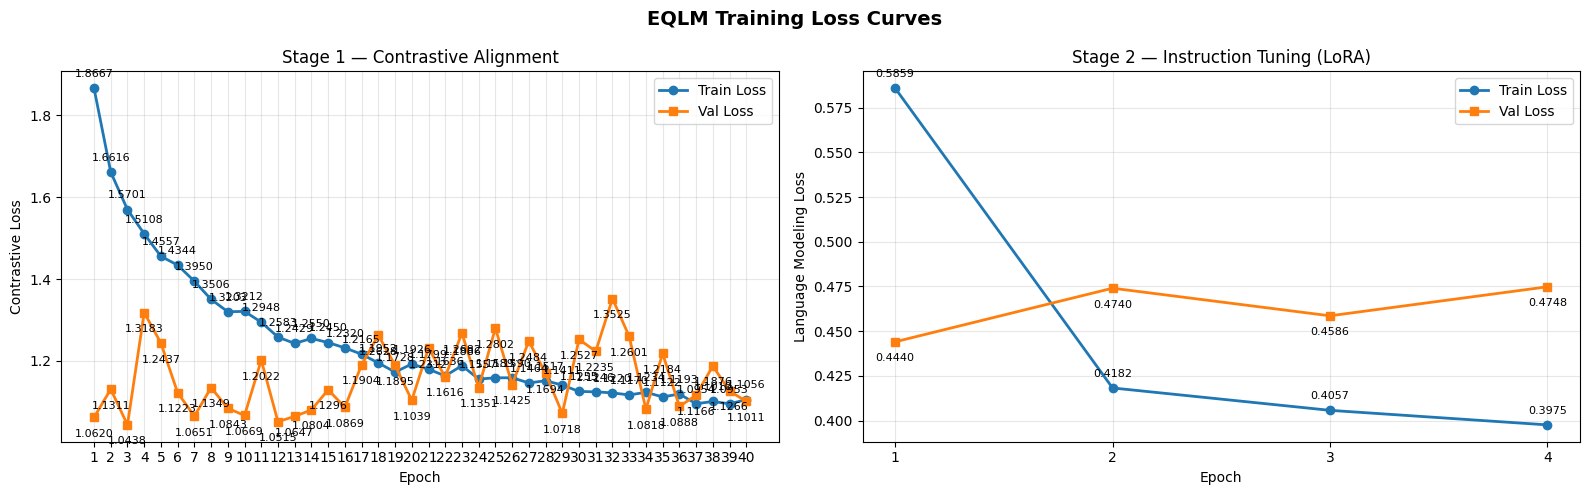

  ✓ Loss curves → /loggerhead/mikedeffino/Code/stage1metric/loss_curves_train_val.png
📥 Loading reports from /loggerhead/mikedeffino/Code/waveform_report_m1_d200_expanded120.jsonl...
  ✓ Loaded 111,075 expert reports
📥 Opening HDF5: /loggerhead/mikedeffino/Code/chunk2.hdf5
  ✓ [EVAL] 1,000 waveform-report pairs
GT length = 98
GEN length = 97

Ground truth:
 Local earthquake waveform at station AHUD: M1.7, 12 km, P at 900, S at 1153, dominant N component.

Generated:
 Local earthquake waveform at station AHUD: M1.8, 29 km, P at 703, S at 965, dominant N component.


In [34]:
import matplotlib.pyplot as plt
save_dir = f"{CODE_DIR}/stage1metric"
os.makedirs(save_dir, exist_ok=True)

save_model(model, tokenizer, save_dir=save_dir)
save_loss_curves(
    stage1_train_loss, stage1_val_loss,
    train_loss, val_loss,
    save_dir=save_dir
)

test_dataset = PreFilteredSTEADDataset(cfg, tokenizer=tokenizer, stage=1, split="eval")
sample = test_dataset[0]
ground_truth = test_dataset.reports[test_dataset.valid_traces[0]]["report"]
generated = generate_report(model, cfg, tokenizer, sample["waveform"])


print("GT length =", len(ground_truth))
print("GEN length =", len(generated))
print("\nGround truth:\n", ground_truth)
print("\nGenerated:\n", generated)

test_dataset.close()

In [35]:
import re
import math
import pandas as pd
from collections import Counter

def extract_fields(text: str):
    text = str(text).strip()
    fields = {
        "station": None,
        "magnitude": None,
        "distance_km": None,
        "p_arrival": None,
        "s_arrival": None,
        "dominant_component": None,
    }

    m = re.search(r"station\s+([A-Za-z0-9]+)", text, re.IGNORECASE)
    if m:
        fields["station"] = m.group(1).upper()

    m = re.search(r"\bM\s*([0-9]+(?:\.[0-9]+)?)\b", text, re.IGNORECASE)
    if m:
        fields["magnitude"] = float(m.group(1))
    else:
        m = re.search(r"magnitude\s+(?:is\s+)?([0-9]+(?:\.[0-9]+)?)", text, re.IGNORECASE)
        if m:
            fields["magnitude"] = float(m.group(1))

    m = re.search(r"([0-9]+(?:\.[0-9]+)?)\s*km\b", text, re.IGNORECASE)
    if m:
        fields["distance_km"] = float(m.group(1))

    m = re.search(r"\bP(?:-wave)?(?:\s+arrival)?(?:\s+is)?(?:\s+annotated)?(?:\s+at)?\s*(?:sample\s*)?([0-9]+)\b", text, re.IGNORECASE)
    if m:
        fields["p_arrival"] = int(m.group(1))
    else:
        m = re.search(r"\bP\s*at\s*([0-9]+)\b", text, re.IGNORECASE)
        if m:
            fields["p_arrival"] = int(m.group(1))

    m = re.search(r"\bS(?:-wave)?(?:\s+arrival)?(?:\s+is)?(?:\s+annotated)?(?:\s+at)?\s*(?:sample\s*)?([0-9]+)\b", text, re.IGNORECASE)
    if m:
        fields["s_arrival"] = int(m.group(1))
    else:
        m = re.search(r"\bS\s*at\s*([0-9]+)\b", text, re.IGNORECASE)
        if m:
            fields["s_arrival"] = int(m.group(1))

    m = re.search(r"dominant\s+([ENZ])\s+component", text, re.IGNORECASE)
    if m:
        fields["dominant_component"] = m.group(1).upper()
    else:
        m = re.search(r"dominant\s+(?:component|channel)\s+(?:is\s+)?([ENZ])\b", text, re.IGNORECASE)
        if m:
            fields["dominant_component"] = m.group(1).upper()

    return fields

def completeness_score(text: str):
    fields = extract_fields(text)
    present = sum(v is not None for v in fields.values())
    return present / len(fields), fields

def clipped_score(err, tol):
    return max(0.0, 1.0 - float(err) / float(tol))

def seismic_grounding_score(gt_text: str, gen_text: str):
    gt = extract_fields(gt_text)
    pred = extract_fields(gen_text)

    station_exact = float(
        gt["station"] is not None and pred["station"] is not None and gt["station"] == pred["station"]
    )
    dominant_exact = float(
        gt["dominant_component"] is not None and pred["dominant_component"] is not None
        and gt["dominant_component"] == pred["dominant_component"]
    )

    mag_err = abs(pred["magnitude"] - gt["magnitude"]) if (
        pred["magnitude"] is not None and gt["magnitude"] is not None
    ) else None
    dist_err = abs(pred["distance_km"] - gt["distance_km"]) if (
        pred["distance_km"] is not None and gt["distance_km"] is not None
    ) else None
    p_err = abs(pred["p_arrival"] - gt["p_arrival"]) if (
        pred["p_arrival"] is not None and gt["p_arrival"] is not None
    ) else None
    s_err = abs(pred["s_arrival"] - gt["s_arrival"]) if (
        pred["s_arrival"] is not None and gt["s_arrival"] is not None
    ) else None

    mag_score = clipped_score(mag_err, 0.3) if mag_err is not None else 0.0
    dist_score = clipped_score(dist_err, 20.0) if dist_err is not None else 0.0
    p_score = clipped_score(p_err, 80.0) if p_err is not None else 0.0
    s_score = clipped_score(s_err, 120.0) if s_err is not None else 0.0

    sgs = (station_exact + dominant_exact + mag_score + dist_score + p_score + s_score) / 6.0

    detail = {
        "station_exact": station_exact,
        "dominant_exact": dominant_exact,
        "mag_err": mag_err,
        "dist_err_km": dist_err,
        "p_err_samples": p_err,
        "s_err_samples": s_err,
        "mag_score": mag_score,
        "dist_score": dist_score,
        "p_score": p_score,
        "s_score": s_score,
    }
    return sgs, detail

def tokenize_for_rouge(text: str):
    return re.findall(r"[A-Za-z0-9\.]+", str(text).lower())

def lcs_length(xs, ys):
    if not xs or not ys:
        return 0
    prev = [0] * (len(ys) + 1)
    for x in xs:
        curr = [0]
        for j, y in enumerate(ys, start=1):
            if x == y:
                curr.append(prev[j - 1] + 1)
            else:
                curr.append(max(prev[j], curr[-1]))
        prev = curr
    return prev[-1]

def rouge_l_f1(reference: str, candidate: str):
    ref_toks = tokenize_for_rouge(reference)
    cand_toks = tokenize_for_rouge(candidate)
    if len(ref_toks) == 0 or len(cand_toks) == 0:
        return 0.0
    lcs = lcs_length(ref_toks, cand_toks)
    prec = lcs / len(cand_toks)
    rec = lcs / len(ref_toks)
    if prec + rec == 0:
        return 0.0
    return 2 * prec * rec / (prec + rec)

def compute_bertscore_batch(references, candidates, device=None):
    try:
        from bert_score import score as bertscore_score
        P, R, F1 = bertscore_score(
            candidates,
            references,
            lang="en",
            device=device,
            rescale_with_baseline=True,
            verbose=True,
        )
        return [float(x) for x in F1]
    except Exception as e:
        print("BERTScore unavailable, skipping. Reason:", repr(e))
        return [None] * len(candidates)

def evaluate_generation_metrics(model, cfg, tokenizer, n_samples=50, instruction=None, save_csv=True):
    eval_dataset = PreFilteredSTEADDataset(cfg, tokenizer=tokenizer, stage=1, split="eval")
    n = min(n_samples, len(eval_dataset))

    refs = []
    gens = []
    rows = []

    for i in range(n):
        sample = eval_dataset[i]
        trace_name = sample["trace_name"]
        gt_text = eval_dataset.reports[trace_name]["report"]
        gen_text = generate_report(model, cfg, tokenizer, sample["waveform"], instruction=instruction)

        comp, gen_fields = completeness_score(gen_text)
        gt_comp, gt_fields = completeness_score(gt_text)
        sgs, detail = seismic_grounding_score(gt_text, gen_text)
        rouge_l = rouge_l_f1(gt_text, gen_text)

        refs.append(gt_text)
        gens.append(gen_text)

        row = {
            "idx": i,
            "trace_name": trace_name,
            "ground_truth": gt_text,
            "generated": gen_text,
            "sgs": sgs,
            "completeness": comp,
            "gt_completeness": gt_comp,
            "rougeL_f1": rouge_l,
            **detail,
            "gt_station": gt_fields["station"],
            "pred_station": gen_fields["station"],
            "gt_magnitude": gt_fields["magnitude"],
            "pred_magnitude": gen_fields["magnitude"],
            "gt_distance_km": gt_fields["distance_km"],
            "pred_distance_km": gen_fields["distance_km"],
            "gt_p_arrival": gt_fields["p_arrival"],
            "pred_p_arrival": gen_fields["p_arrival"],
            "gt_s_arrival": gt_fields["s_arrival"],
            "pred_s_arrival": gen_fields["s_arrival"],
            "gt_dominant_component": gt_fields["dominant_component"],
            "pred_dominant_component": gen_fields["dominant_component"],
        }
        rows.append(row)

    bertscores = compute_bertscore_batch(
        refs,
        gens,
        device=cfg.device if str(cfg.device).startswith("cuda") else "cpu",
    )
    for row, bs in zip(rows, bertscores):
        row["bertscore_f1"] = bs

    df = pd.DataFrame(rows)

    summary = {
        "num_samples": len(df),
        "mean_SGS": float(df["sgs"].mean()),
        "mean_completeness": float(df["completeness"].mean()),
        "mean_ROUGE_L_F1": float(df["rougeL_f1"].mean()),
        "mean_BERTScore_F1": float(df["bertscore_f1"].dropna().mean()) if df["bertscore_f1"].notna().any() else None,
        "station_exact_rate": float(df["station_exact"].mean()),
        "dominant_exact_rate": float(df["dominant_exact"].mean()),
        "mean_mag_err": float(df["mag_err"].dropna().mean()) if df["mag_err"].notna().any() else None,
        "mean_dist_err_km": float(df["dist_err_km"].dropna().mean()) if df["dist_err_km"].notna().any() else None,
        "mean_p_err_samples": float(df["p_err_samples"].dropna().mean()) if df["p_err_samples"].notna().any() else None,
        "mean_s_err_samples": float(df["s_err_samples"].dropna().mean()) if df["s_err_samples"].notna().any() else None,
    }

    print("=" * 80)
    print("GENERATION EVALUATION SUMMARY")
    print("=" * 80)
    for k, v in summary.items():
        print(f"{k}: {v}")

    print("\nSample rows:")
    display_cols = [
        "trace_name", "sgs", "completeness", "rougeL_f1", "bertscore_f1",
        "station_exact", "dominant_exact", "mag_err", "dist_err_km", "p_err_samples", "s_err_samples"
    ]
    display(df[display_cols].head(10))

    if save_csv:
        save_dir = f"{CODE_DIR}/stage1metric"
        os.makedirs(save_dir, exist_ok=True)
        csv_path = os.path.join(save_dir, "generation_metrics.csv")
        df.to_csv(csv_path, index=False)
        print(f"\nSaved per-sample metrics to: {csv_path}")

    eval_dataset.close()
    return df, summary

metrics_df, metrics_summary = evaluate_generation_metrics(
    model,
    cfg,
    tokenizer,
    n_samples=20,
    instruction="Describe this seismic event in one sentence.",
    save_csv=True,
)


📥 Loading reports from /loggerhead/mikedeffino/Code/waveform_report_m1_d200_expanded120.jsonl...
  ✓ Loaded 111,075 expert reports
📥 Opening HDF5: /loggerhead/mikedeffino/Code/chunk2.hdf5
  ✓ [EVAL] 1,000 waveform-report pairs


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


  0%|          | 0/1 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 0.09 seconds, 224.63 sentences/sec
GENERATION EVALUATION SUMMARY
num_samples: 20
mean_SGS: 0.521701388888889
mean_completeness: 1.0
mean_ROUGE_L_F1: 0.7833333333333334
mean_BERTScore_F1: 0.9049144297838211
station_exact_rate: 0.95
dominant_exact_rate: 0.95
mean_mag_err: 0.38999999999999996
mean_dist_err_km: 5.05
mean_p_err_samples: 175.9
mean_s_err_samples: 169.5

Sample rows:


,trace_name,sgs,completeness,rougeL_f1,bertscore_f1,station_exact,dominant_exact,mag_err,dist_err_km,p_err_samples,s_err_samples
0,AHUD.HV_20180506042619_EV,0.469444,1.0,0.777778,0.893308,1.0,1.0,0.1,17.0,197,188
1,AHUD.HV_20180506060130_EV,0.458333,1.0,0.777778,0.914190,1.0,1.0,0.4,5.0,197,193
2,AHUD.HV_20180506072221_EV,0.580556,1.0,0.777778,0.891933,1.0,1.0,0.3,4.0,103,38
3,AHUD.HV_20180506084248_EV,0.540278,1.0,0.833333,0.950057,1.0,1.0,0.3,0.0,99,91
4,AHUD.HV_20180506101131_EV,0.452778,1.0,0.777778,0.902583,1.0,1.0,0.1,19.0,307,341
5,AHUD.HV_20180506102045_EV,0.400000,1.0,0.777778,0.915642,1.0,1.0,0.5,12.0,100,209
6,AHUD.HV_20180506124324_EV,0.552778,1.0,0.777778,0.915677,1.0,1.0,0.1,7.0,200,263
7,AHUD.HV_20180506235713_EV,0.775694,1.0,0.777778,0.951226,1.0,1.0,0.5,1.0,1,34
8,AHUD.HV_20180507002828_EV,0.483333,1.0,0.777778,0.936912,1.0,1.0,0.4,2.0,105,204
9,AHUD.HV_20180507021002_EV,0.491667,1.0,0.777778,0.894108,1.0,1.0,0.3,1.0,307,306



Saved per-sample metrics to: /loggerhead/mikedeffino/Code/stage1metric/generation_metrics.csv
